In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:\\datafile\\website_data_analysis.csv")
df.head()

,website,visits,bounce_rate,conversion_rate,days_of_week,unique_visitors,referral_source,revenue
0,boss.com,5000,20,3.0,Monday,3000,Google,1000
1,python.com,3500,25,2.0,Tuesday,2800,Facebook,800
2,wild.com,6000,15,4.0,Wednesday,3900,Twitter,1200
3,cat.com,4500,30,1.5,Thursday,3500,Instagram,700
4,kit.com,5500,18,3.5,Friday,3700,Yahoo,1000


In [3]:
avg_visit = df.groupby('website')['visits'].mean()
avg_visit

website
Childcare.net         1400.0
CodeCrushers.org      2900.0
CraftyCorner.com      3000.0
FinFit.net            3400.0
FoodieFrenzy.com      3200.0
Garden.com            1300.0
GoldSales.com         1200.0
HealthHQ.net          2500.0
Love.net              3400.0
MindMelders.net       2600.0
MusicMaven.com        3100.0
ScribeMind.com        3200.0
SmartGardeners.net    2700.0
TravelCove.net        2800.0
boss.com              4500.0
cat.com               4500.0
kit.com               5500.0
python.com            3500.0
wild.com              5050.5
Name: visits, dtype: float64

In [4]:
df['puv'] = df['visits']/df['unique_visitors']
df['puv'] = df['puv'].round(2)
df.head()

,website,visits,bounce_rate,conversion_rate,days_of_week,unique_visitors,referral_source,revenue,puv
0,boss.com,5000,20,3.0,Monday,3000,Google,1000,1.67
1,python.com,3500,25,2.0,Tuesday,2800,Facebook,800,1.25
2,wild.com,6000,15,4.0,Wednesday,3900,Twitter,1200,1.54
3,cat.com,4500,30,1.5,Thursday,3500,Instagram,700,1.29
4,kit.com,5500,18,3.5,Friday,3700,Yahoo,1000,1.49


In [5]:
top_5_web = df.sort_values(by = 'visits', ascending = False).head(5)
top_5_web

,website,visits,bounce_rate,conversion_rate,days_of_week,unique_visitors,referral_source,revenue,puv
2,wild.com,6000,15,4.0,Wednesday,3900,Twitter,1200,1.54
4,kit.com,5500,18,3.5,Friday,3700,Yahoo,1000,1.49
0,boss.com,5000,20,3.0,Monday,3000,Google,1000,1.67
3,cat.com,4500,30,1.5,Thursday,3500,Instagram,700,1.29
6,wild.com,4101,20,4.0,Sunday,4000,Instagram,900,1.03


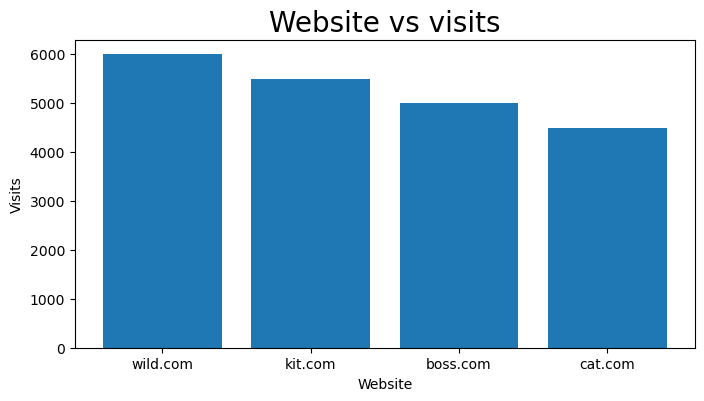

In [6]:
plt.figure(figsize = (8, 4))
plt.bar(top_5_web['website'], top_5_web['visits'])
plt.xlabel('Website')
plt.ylabel('Visits')
plt.title('Website vs visits', fontsize = 20)
plt.show()

In [7]:
df.head()

,website,visits,bounce_rate,conversion_rate,days_of_week,unique_visitors,referral_source,revenue,puv
0,boss.com,5000,20,3.0,Monday,3000,Google,1000,1.67
1,python.com,3500,25,2.0,Tuesday,2800,Facebook,800,1.25
2,wild.com,6000,15,4.0,Wednesday,3900,Twitter,1200,1.54
3,cat.com,4500,30,1.5,Thursday,3500,Instagram,700,1.29
4,kit.com,5500,18,3.5,Friday,3700,Yahoo,1000,1.49


In [8]:
avg_bounce_rate = df.groupby('days_of_week')['bounce_rate'].mean()
avg_bounce_rate.head()

days_of_week
Friday      15.666667
Monday      21.333333
Saturday    16.000000
Sunday      18.333333
Thursday    20.666667
Name: bounce_rate, dtype: float64

In [9]:
sorted_avg = avg_bounce_rate.sort_values(ascending = False)


In [10]:
highest_rate = sorted_avg.head(1).iloc[0]
highest = sorted_avg.index[0]

In [11]:
print(f'day with max bounce rate {highest} and rate is {highest_rate:.2f}')

day with max bounce rate Monday and rate is 21.33


In [12]:
df.head()

,website,visits,bounce_rate,conversion_rate,days_of_week,unique_visitors,referral_source,revenue,puv
0,boss.com,5000,20,3.0,Monday,3000,Google,1000,1.67
1,python.com,3500,25,2.0,Tuesday,2800,Facebook,800,1.25
2,wild.com,6000,15,4.0,Wednesday,3900,Twitter,1200,1.54
3,cat.com,4500,30,1.5,Thursday,3500,Instagram,700,1.29
4,kit.com,5500,18,3.5,Friday,3700,Yahoo,1000,1.49


In [14]:
df_group = df.groupby('days_of_week')['unique_visitors'].mean()
df_group.head()

days_of_week
Friday      2100.000000
Monday      2666.666667
Saturday    2033.333333
Sunday      2366.666667
Thursday    2333.333333
Name: unique_visitors, dtype: float64

In [17]:
df_group.index

Index(['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday'],
      dtype='object', name='days_of_week')

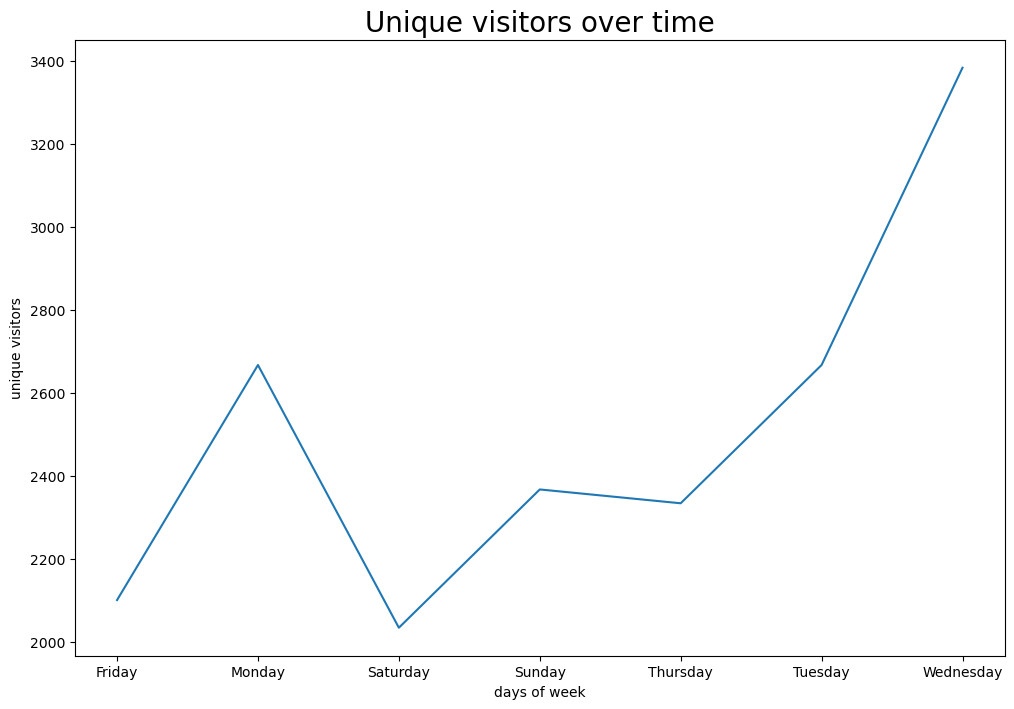

In [20]:
import seaborn as sns

plt.figure(figsize =(12, 8))

sns.lineplot(x =df_group.index, y = df_group)
plt.xlabel('days of week')
plt.ylabel('unique visitors')
plt.title('Unique visitors over time', fontsize = 20)
plt.show()


In [25]:
grouped_df = df.groupby(['days_of_week', 'referral_source'])[['visits', 'revenue']].mean()
grouped_df.head()

visits  revenue
days_of_week referral_source                 
Friday       Instagram        2100.0   1450.0
             Yahoo            5500.0   1000.0
Monday       Google           5000.0   1000.0
             Instagram        2600.0    700.0
             Reddit           3200.0    900.0